In [ ]:
!pip install gym==0.21.0 -q
!pip install gym-super-mario-bros==7.4.0 -q
!pip install nes-py==8.2.1 -q
!pip install stable-baselines3[extra] -q
!pip install opencv-python -q

import pathlib, inspect

# Patch 1 — nes_py/_rom.py
import nes_py._rom as rom_module
rom_path = pathlib.Path(inspect.getfile(rom_module))
code = rom_path.read_text()
code = code.replace(
    'return self.prg_rom_start + self.prg_rom_size * 2**10',
    'return int(self.prg_rom_start) + int(self.prg_rom_size) * 1024'
)
code = code.replace(
    'return self.chr_rom_start + self.chr_rom_size * 2**10',
    'return int(self.chr_rom_start) + int(self.chr_rom_size) * 1024'
)
rom_path.write_text(code)
print("✅ Patch 1 nes_py/_rom.py OK")

# Patch 2 — gym_super_mario_bros/smb_env.py
import gym_super_mario_bros.smb_env as smb_module
smb_path = pathlib.Path(inspect.getfile(smb_module))
code = smb_path.read_text()
code = code.replace(
    'return self.ram[0x6d] * 0x100 + self.ram[0x86]',
    'return int(self.ram[0x6d]) * 0x100 + int(self.ram[0x86])'
)
smb_path.write_text(code)
print("✅ Patch 2 smb_env.py OK")

print("\n⚠️  Restart le runtime maintenant !")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.1 MB/s eta 0:00:

In [ ]:
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback

N_ENVS = 10

vec_env = DummyVecEnv([make_mario_env(i) for i in range(N_ENVS)])
vec_env = VecTransposeImage(vec_env)

eval_env = DummyVecEnv([make_mario_env(99)])
eval_env = VecTransposeImage(eval_env)

checkpoint_cb = CheckpointCallback(
    save_freq=50_000 // N_ENVS,
    save_path='./checkpoints/',
    name_prefix='mario_ppo'
)

eval_cb = EvalCallback(
    eval_env,
    eval_freq=50_000 // N_ENVS,
    best_model_save_path='./best_model/',
    n_eval_episodes=5,
    verbose=1
)

model = PPO(
    "CnnPolicy",
    vec_env,
    learning_rate=2.5e-4,
    n_steps=512,
    batch_size=64,
    n_epochs=4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=1,
    tensorboard_log="./logs/",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

model.learn(
    total_timesteps=500_000,
    callback=[checkpoint_cb, eval_cb],
    progress_bar=True
)

model.save("mario_ppo_500k")
print("✅ Training terminé !")

/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment SuperMarioBros-v0 is out of date. You should consider upgrading to version `v3`.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


Using cuda device
Logging to ./logs/PPO_1


Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 121         |
|    mean_reward          | 110         |
| time/                   |             |
|    total_timesteps      | 450000      |
| train/                  |             |
|    approx_kl            | 0.018539423 |
|    clip_fraction        | 0.0838      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.491      |
|    explained_variance   | 0.391       |
|    learning_rate        | 0.00025     |
|    loss                 | 51.9        |
|    n_updates            | 348         |
|    policy_gradient_loss | 0.00256     |
|    value_loss           | 137         |
-----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 188      |
|    ep_rew_mean     | 144      |
| time/              |          |
|    fps             | 63       |
|    iterations      | 88       |
|    t

Eval num_timesteps=500000, episode_reward=110.00 +/- 0.00

Episode length: 121.00 +/- 0.00

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 121         |
|    mean_reward          | 110         |
| time/                   |             |
|    total_timesteps      | 500000      |
| train/                  |             |
|    approx_kl            | 0.024062667 |
|    clip_fraction        | 0.156       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.671      |
|    explained_variance   | 0.579       |
|    learning_rate        | 0.00025     |
|    loss                 | 37.4        |
|    n_updates            | 388         |
|    policy_gradient_loss | 0.0141      |
|    value_loss           | 70.8        |
-----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 256      |
|    ep_rew_mean     | 209      |
| time/              |          |
|    fps             | 64       |
|    iterations      | 98       |
|    t

✅ Training terminé !


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Modele charge !
Recherche du meilleur episode...
Episode 1/250 | X: 1264 | Score: 500 | Frames: 511
  --> Nouveau meilleur ! X=1264 score=500 🎮
Episode 2/250 | X: 701 | Score: 200 | Frames: 180
Episode 3/250 | X: 1135 | Score: 400 | Frames: 489
Episode 4/250 | X: 1780 | Score: 600 | Frames: 367
  --> Nouveau meilleur ! X=1780 score=600 🎮
Episode 5/250 | X: 692 | Score: 500 | Frames: 246
Episode 6/250 | X: 706 | Score: 300 | Frames: 329
Episode 7/250 | X: 1414 | Score: 600 | Frames: 348
Episode 8/250 | X: 299 | Score: 0 | Frames: 106
Episode 9/250 | X: 1410 | Score: 300 | Frames: 301
Episode 10/250 | X: 706 | Score: 200 | Frames: 200
Episode 11/250 | X: 722 | Score: 0 | Frames: 294
Episode 12/250 | X: 722 | Score: 0 | Frames: 242
Episode 13/250 | X: 294 | Score: 600 | Frames: 188
Episode 14/250 | X: 294 | Score: 200 | Frames: 192
Episode 15/250 | X: 285 | Score: 200 | Frames: 190
Episode 16/250 | X: 1411 | Score: 600 | Frames: 468
Episode 17/250 | X: 1397 | Score: 900 | Frames: 425
Epis

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Fichiers telecharges !


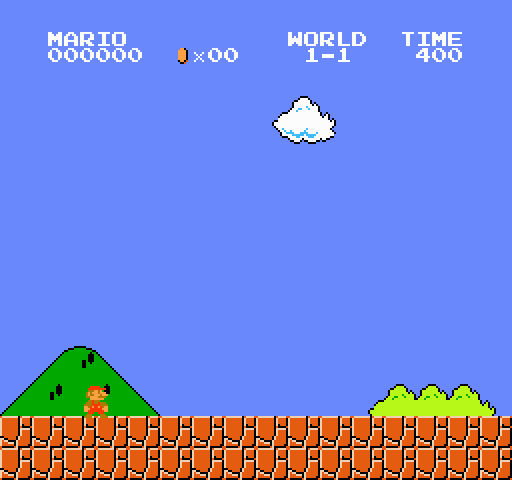

In [ ]:
import numpy as np
import gym
np.bool8 = np.bool_
np.float_ = np.float64

import cv2, collections, imageio
import gym_super_mario_bros
from gym_super_mario_bros.actions import SIMPLE_MOVEMENT
from nes_py.wrappers import JoypadSpace
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage
from stable_baselines3.common.monitor import Monitor
import gymnasium
from IPython.display import Image as IPImage, display

# ============ ENV ============
class MarioEnv(gymnasium.Env):
    metadata = {"render_modes": ["rgb_array"]}
    def __init__(self):
        self._env = gym_super_mario_bros.make('SuperMarioBros-v0')
        self._env = JoypadSpace(self._env, SIMPLE_MOVEMENT)
        self._skip = 4
        self._frames = collections.deque(maxlen=4)
        self.observation_space = gymnasium.spaces.Box(low=0, high=255, shape=(84, 84, 4), dtype=np.uint8)
        self.action_space = gymnasium.spaces.Discrete(self._env.action_space.n)

    def _preprocess(self, obs):
        gray = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        return cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)

    def _get_obs(self):
        return np.stack(list(self._frames), axis=-1)

    def reset(self, seed=None, options=None):
        obs = self._env.reset()
        frame = self._preprocess(obs)
        for _ in range(4):
            self._frames.append(frame)
        return self._get_obs(), {}

    def step(self, action):
        action = int(np.asarray(action).flat[0])
        total_reward = 0.0
        terminated = False
        info = {}
        for _ in range(self._skip):
            obs, reward, done, info = self._env.step(action)
            total_reward += reward
            if done:
                terminated = True
                break
        self._frames.append(self._preprocess(obs))
        return self._get_obs(), float(np.sign(total_reward)), terminated, False, info

    def render(self):
        return self._env.render(mode='rgb_array')

    def close(self):
        self._env.close()

def make_mario_env(rank=0):
    def _init():
        env = MarioEnv()
        env = Monitor(env)
        return env
    return _init

# ============ CHARGE MODELE ============
model = PPO.load("best_model/best_model")
print("Modele charge !")

env = DummyVecEnv([make_mario_env(0)])
env = VecTransposeImage(env)

# ============ 250 EPISODES ============
N_EPISODES = 250
best_frames = []
best_x = 0

print("Recherche du meilleur episode...")

for ep in range(N_EPISODES):
    obs = env.reset()
    done = [False]
    ep_frames = []
    ep_steps = 0

    while not done[0]:
        action, _ = model.predict(obs, deterministic=False)
        obs, reward, done, info = env.step(action)
        frame = env.envs[0].env._env.render(mode='rgb_array')
        frame_big = cv2.resize(
            frame,
            (frame.shape[1]*2, frame.shape[0]*2),
            interpolation=cv2.INTER_NEAREST
        )
        ep_frames.append(frame_big)
        ep_steps += 1
        if ep_steps >= 3000:
            break

    x_pos = info[0].get('x_pos', 0)
    score = info[0].get('score', 0)
    print(f"Episode {ep+1}/250 | X: {x_pos} | Score: {score} | Frames: {ep_steps}")

    if x_pos > best_x:
        best_x = x_pos
        best_frames = ep_frames.copy()
        print(f"  --> Nouveau meilleur ! X={best_x} score={score} 🎮")

print(f"\n✅ Meilleur episode : X={best_x}")
print(f"Total frames : {len(best_frames)}")

# ============ SAUVEGARDE GIF ============
print("Sauvegarde GIF...")
imageio.mimsave('mario_best.gif', best_frames[::2], duration=33)
print("✅ mario_best.gif sauvegarde !")

# ============ SAUVEGARDE MP4 ============
print("Sauvegarde MP4...")
h, w = best_frames[0].shape[:2]
out = cv2.VideoWriter(
    'mario_best.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    30,
    (w, h)
)
for f in best_frames:
    out.write(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
out.release()
print("✅ mario_best.mp4 sauvegarde !")

# ============ TELECHARGE LES FICHIERS ============
from google.colab import files
files.download('mario_best.gif')
files.download('mario_best.mp4')
print("✅ Fichiers telecharges !")

# ============ AFFICHE DANS COLAB ============
display(IPImage('mario_best.gif'))